---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Topic**: You Can Just Build Things

🚫 **Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

## Welcome!

In our firstfour lectures, we've covered how
1. We can call LLMs via APIs and get structured responses
2. We can build lexical search with BM25
3. We can build semantic search with embeddings
4. We can combine lexical and semantic search into hybrid search

Today you will put it all together by building a Retrieval Augmented Generation (RAG) system.
- This is a question-answering bot that can answer questions about Fordham University
- You will use real data scraped from the Fordham website.


Your RAG pipeline will look like this:

```
User Question
     ↓
1. RETRIEVE: Find relevant documents (search!)
     ↓
2. AUGMENT: Stuff those documents into a prompt
     ↓
3. GENERATE: Ask an LLM to answer using the context
     ↓
Answer
```


---

# 1. Look at your data

In `data/fordham-website.zip` you'll find **~9,500 Markdown files** scraped from Fordham's website. Each file is one page — admissions info, program descriptions, faculty pages, financial aid, campus life, and more.

Your task: **look at the data**
- The first step in any AI engineering or data science project should always be to familiarize yourself with the data.
- I cannot stress this enough.. without this step, it's hard to build anything useful.

Tips:
- Unzip the archive and look at some of the files. 
- Open a few in a text editor. 
- Get a feel for what you're working with.
- The first line of every file is always the **URL** of the page it was scraped from. The rest is the page content converted to Markdown. Here's an example — `gabelli-school-of-business_veterans.md`:

```markdown
https://www.fordham.edu/gabelli-school-of-business/veterans

# Military Veterans & Active Duty Members of the Military

## Transform Your Knowledge & Skills Into a Business Career for the Future

As a veteran or an active duty member of the United States Armed Services,
you have gained or are currently acquiring the invaluable organizational,
leadership, analytics, and technical knowledge and skills that hiring
managers seek. These transferrable skills provide a major advantage in
emerging, business-related industries where innovation, a global mind-set,
and the ability to lead individuals and teams in the continuously evolving
work environment, are critical for success.

By completing a graduate or undergraduate business degree at the Gabelli
School of Business, you can prepare for a lifelong career in some of
today's fastest-growing fields. ...

### Study at a Top-Ranked, Military-Friendly University

The Gabelli School of Business is part of Fordham University, the only
New York City university to be among those ranked "Best for Vets" by
Military Times. ...

### Learn How the Yellow Ribbon Program Works

The Yellow Ribbon GI Education Enhancement Program, or the Yellow Ribbon
Program, is a part of the Post-9/11 Veterans Educational Assistance Act
of 2008. ...
```

The filenames mirror the URL structure — underscores replace path separators (e.g. `gabelli-school-of-business_veterans.md` came from `/gabelli-school-of-business/veterans`). Some files are short (a few lines), others are quite long.

- Once you've looked around, load the files into Python. Python's built-in `zipfile` module can read zip archives without extracting to disk. Load them into a list of dictionaries or a DataFrame with at least two fields: the filename (or a clean page name) and the content

In [1]:
import pandas as pd
pd.__version__


'2.3.3'

In [4]:
from pathlib import Path

data_files = sorted([p.name for p in Path("data").iterdir()])
data_files


['.DS_Store',
 'fordham-website',
 'wayfair-labels.csv',
 'wayfair-products.csv',
 'wayfair-queries.csv']

In [5]:
import zipfile
import pandas as pd
import os
import pathlib

def load_fordham_data(source_path):
    data = []
    
    # 1. Check if it's a zip file
    if source_path.endswith('.zip') and os.path.exists(source_path):
        print(f"Loading from zip: {source_path}")
        with zipfile.ZipFile(source_path, 'r') as z:
            file_list = [f for f in z.namelist() if f.endswith('.md')]
            for file_name in file_list:
                with z.open(file_name) as f:
                    try:
                        content = f.read().decode('utf-8')
                    except UnicodeDecodeError:
                        continue
                    
                    lines = content.split('\n', 1)
                    url = lines[0].strip() if lines else ""
                    body = lines[1].strip() if len(lines) > 1 else ""
                    
                    data.append({
                        "filename": file_name,
                        "url": url,
                        "content": body
                    })
                    
    # 2. Check if it's a directory (Robust Fallback)
    elif os.path.exists(source_path) and os.path.isdir(source_path):
        print(f"Loading from directory: {source_path}")
        path = pathlib.Path(source_path)
        files = list(path.glob('*.md'))
        print(f"Found {len(files)} markdown files.")
        
        for file_path in files:
             try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    lines = f.readlines()
                    if not lines: continue
                    
                    url = lines[0].strip()
                    content = "".join(lines[1:]).strip()
                    
                    data.append({
                        "filename": file_path.name,
                        "url": url,
                        "content": content
                    })
             except Exception as e:
                print(f"Error reading {file_path}: {e}")
                
    else:
        print(f"Source not found or invalid: {source_path}")
        # Try default locations if provided path fails
        fallback_dir = 'data/fordham-website'
        if source_path != fallback_dir and os.path.exists(fallback_dir) and os.path.isdir(fallback_dir):
             print(f"Fallback: Loading from {fallback_dir}")
             return load_fordham_data(fallback_dir) # Recursive call
             
        return pd.DataFrame()

    return pd.DataFrame(data)

# Usage - Point to the directory since you extracted it
source_path = 'data/fordham-website' 
df = load_fordham_data(source_path)

print(f"Loaded {len(df)} documents.")
print(df.head())

Loading from directory: data/fordham-website
Found 9530 markdown files.
Loaded 9530 documents.
                                            filename  \
0  about_living-the-mission_campus-ministry_catho...   
1  academics_centers-and-institutes_center-for-et...   
2  graduate-school-of-arts-and-sciences_student-r...   
3  academics_departments_psychology_graduate-prog...   
4  academics_departments_african--african-america...   

                                                 url  \
0  https://www.fordham.edu/about/living-the-missi...   
1  https://www.fordham.edu/academics/centers-and-...   
2  https://www.fordham.edu/graduate-school-of-art...   
3  https://www.fordham.edu/academics/departments/...   
4  https://www.fordham.edu/academics/departments/...   

                                             content  
0  # Ministry of Music\n\n\nFordham offers each s...  
1  # Advanced Certificate in Health Care Ethics C...  
2  Skip to Main Content\nGraduate School of Arts ...  
3  # Alumni

---

# 2. Chunk the Documents

Some of the pages could be too long to embed as a single unit. Down the line, the pages may be too long to stuff into the LLM's prompt during the generation step. As such, most of the RAG systems will break down big documents into into smaller **chunks**.

> 📚 **TERM: Chunking**  
> Splitting documents into smaller, self-contained pieces for embedding and retrieval. The goal is chunks that are small enough to be specific, but large enough to be meaningful.

Your task: **write a function that splits each document into chunks.**

Things to think about:
- What's a reasonable chunk size? (Think about what fits in a prompt vs. what's too vague)
- Should you split on sentences? Paragraphs? A fixed character/word count?
- Should chunks overlap? What happens if an answer spans two chunks?
- How do you keep track of which document each chunk came from? You may need that information down the line.

In [6]:
# Placeholder for your implementation
def chunk_text(text, chunk_size=800, overlap=150):
    chunks = []
    if not text:
        return chunks
        
    start = 0
    text_len = len(text)
    
    while start < text_len:
        end = start + chunk_size
        chunk = text[start:end]
        chunks.append(chunk)
        # Move the start pointer forward
        step = chunk_size - overlap
        if step <= 0: step = 1 # Avoid infinite loop
        start += step
        
    return chunks

def process_to_chunks(df):
    chunked_data = []
    
    for index, row in df.iterrows():
        # Get content, default to empty string if missing
        content = row.get('content', '')
        if not isinstance(content, str): content = ""
            
        # Split the body content into pieces
        text_chunks = chunk_text(content)
        
        for i, chunk_content in enumerate(text_chunks):
            # Only add non-empty chunks if you prefer
            if not chunk_content.strip(): continue
                
            chunked_data.append({
                "chunk_id": f"{row['filename']}_{i}",
                "source_url": row['url'],
                "content": chunk_content.strip(),
                "parent_file": row['filename']
            })
            
    return pd.DataFrame(chunked_data)

# Apply the function to create df_chunks
df_chunks = process_to_chunks(df)

print(f"Generated {len(df_chunks)} chunks from {len(df)} documents.")
print(df_chunks.head())

Generated 66082 chunks from 9530 documents.
                                            chunk_id  \
0  about_living-the-mission_campus-ministry_catho...   
1  about_living-the-mission_campus-ministry_catho...   
2  about_living-the-mission_campus-ministry_catho...   
3  about_living-the-mission_campus-ministry_catho...   
4  about_living-the-mission_campus-ministry_catho...   

                                          source_url  \
0  https://www.fordham.edu/about/living-the-missi...   
1  https://www.fordham.edu/about/living-the-missi...   
2  https://www.fordham.edu/about/living-the-missi...   
3  https://www.fordham.edu/about/living-the-missi...   
4  https://www.fordham.edu/about/living-the-missi...   

                                             content  \
0  # Ministry of Music\n\n\nFordham offers each s...   
1  itan area over the live radio broadcast by WFU...   
2  mble:**Liturgical/Worship - Mixed Voices**Memb...   
3  ers at the 7:00 p.m. Sunday Mass in the Univer...   
4 

---

# 3. Embed the Chunks

Now we need to turn each chunk into a vector so we can search over them. You've done this before in Lecture 4.

Your task: **embed all chunks using an embedding model.**

Tips:
- You could use a local model, or API model. What are the tradeoffs?
- This will take a while if you do it serially. You might want to use async/batch.
- Once you've created your embeddings, you may want to save them to disk so you don't have to redo this step every time
- You'll need to embed queries with the **same model** at search time

In [7]:
# Placeholder for your implementation
from sentence_transformers import SentenceTransformer
import numpy as np

# 1. Initialize the model
# 'all-MiniLM-L6-v2' is a small, fast model great for local use
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Get the list of texts to embed
# We use the 'content' column of our chunks dataframe
chunk_texts = df_chunks['content'].tolist()

print(f"Embedding {len(chunk_texts)} chunks...")

# 3. Embed the chunks
# The model handles batching automatically
embeddings = model.encode(chunk_texts, show_progress_bar=True)

# 4. Add embeddings to the dataframe 
df_chunks['embedding'] = list(embeddings)

print("Embedding complete.")
print(df_chunks.head())

/Users/pavitravenkatesh/Desktop/ai-engineering-fordham-backup/ai-engineering-fordham/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Embedding 66082 chunks...


Batches:   0%|          | 0/2066 [00:00<?, ?it/s]

Embedding complete.
                                            chunk_id  \
0  about_living-the-mission_campus-ministry_catho...   
1  about_living-the-mission_campus-ministry_catho...   
2  about_living-the-mission_campus-ministry_catho...   
3  about_living-the-mission_campus-ministry_catho...   
4  about_living-the-mission_campus-ministry_catho...   

                                          source_url  \
0  https://www.fordham.edu/about/living-the-missi...   
1  https://www.fordham.edu/about/living-the-missi...   
2  https://www.fordham.edu/about/living-the-missi...   
3  https://www.fordham.edu/about/living-the-missi...   
4  https://www.fordham.edu/about/living-the-missi...   

                                             content  \
0  # Ministry of Music\n\n\nFordham offers each s...   
1  itan area over the live radio broadcast by WFU...   
2  mble:**Liturgical/Worship - Mixed Voices**Memb...   
3  ers at the 7:00 p.m. Sunday Mass in the Univer...   
4  #### What type of music

---

# 4. Retrieve

Now build the **R** in RAG. Given a user's question, find the most relevant chunks.

Your task: **write a retrieval function that takes a question and returns the most relevant chunks.**

Tips:
- You can use lexical or semantic search or both!
- How many chunks should you retrieve? Too few and you might miss the answer; too many and you'll overwhelm the LLM (and pay more tokens)
- Try a few test questions and eyeball whether the retrieved chunks are relevant
- Try a few questions and see what comes back. For example:
  - "What programs does the Gabelli School of Business offer?"
  - "How do I apply for financial aid?"
  - "Where is Fordham's campus?"

In [8]:
import numpy as np

# Precompute once
emb_matrix = np.stack(df_chunks["embedding"].values).astype("float32")
emb_matrix = emb_matrix / np.linalg.norm(emb_matrix, axis=1, keepdims=True)

def retrieve(query, top_k=5):
    q = model.encode([query])[0].astype("float32")
    q = q / np.linalg.norm(q)

    scores = emb_matrix @ q
    top_idx = np.argsort(scores)[::-1][:top_k]
    out = df_chunks.iloc[top_idx].copy()
    out["score"] = scores[top_idx]
    return out


In [9]:
test_queries = [
    "What programs does the Gabelli School of Business offer?",
    "How do I apply for financial aid?",
    "Where is Fordham's campus?"
]
for q in test_queries:
    print(f"\nQuestion: {q}")
    results = retrieve(q, top_k=5)
    for _, row in results.iterrows():
        print(f"  - ({row['score']:.3f}) [{row['parent_file']}] {row['source_url']} | {row['content'][:120]}...")



Question: What programs does the Gabelli School of Business offer?
  - (0.766) [gabelli-school-of-business_academic-programs-and-admissions.md] https://www.fordham.edu/gabelli-school-of-business/academic-programs-and-admissions | # Gabelli Academic Programs and Admissions

Our wide-ranging business school programs won’t just shape your career – the...
  - (0.764) [academics_colleges-and-schools_graduate-schools.md] https://www.fordham.edu/academics/colleges-and-schools/graduate-schools | new programs and majors that reflect the hottest industries as well as the current challenges facing the global communit...
  - (0.745) [info_23872_transfer_credit_policies_and_procedures.md] https://www.fordham.edu/info/23872/transfer_credit_policies_and_procedures | l-of-business/academic-programs-and-admissions/undergraduate-programs/which-campus/lincoln-center/)) and a corresponding...
  - (0.745) [undergraduate-admission_apply_how-to-apply_transfer-students_after-submission-of-the-application.md]

---

# 5. Generate

Now build the **G** in RAG. Take the retrieved chunks and pass them to an LLM along with the user's question.

Your task: **write a function that takes a question and the retrieved chunks, builds a prompt, and calls an LLM to generate an answer.**

Tips:
- How should you structure the prompt? The LLM needs to know: (1) what is the context of the application, (2) what is the question, (3) what it should include in its answer
- What should the LLM do if the context doesn't contain the answer?
- Start with a cheap model; try a better one when you've figured out the pipeline

In [10]:
# Placeholder for your implementation

from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv()
client = OpenAI()


In [11]:
def build_prompt(question, retrieved_df):
    context_blocks = []

    for _, row in retrieved_df.iterrows():
        block = f"""
SOURCE: {row['source_url']}
{row['content']}
"""
        context_blocks.append(block)

    context = "\n---\n".join(context_blocks)

    prompt = f"""
You are a Fordham University information assistant.

Use ONLY the context below to answer the question.
If the answer is not in the context, say:
"I don't know based on the provided context."

CONTEXT:
{context}

QUESTION:
{question}

ANSWER:
"""
    return prompt


In [12]:
def generate_answer(question, retrieved_df, model="gpt-4o-mini"):
    prompt = build_prompt(question, retrieved_df)

    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=400
    )

    return response.choices[0].message.content



In [13]:
def rag(question, top_k=5):
    retrieved = retrieve(question, top_k=top_k)
    answer = generate_answer(question, retrieved)

    return answer


In [14]:
print(rag("How do I apply for financial aid?"))


To apply for financial aid at Fordham University, applicants should complete the Free Application for Federal Student Aid (FAFSA) to be considered for federal aid and the CSS Profile for institutional aid. It is important to check the specific financial aid deadlines associated with your choice of admission application (Early Action, Early Decision, or Regular Decision). Once admitted, you can log onto your Financial Aid Portal to view and accept your awards online.


---

# 6. Wire everything together

Combine the previous steps into a simple function that takes in a question and returns an answer.

Your task: **write a `rag(question)` function that retrieves relevant chunks and generates an answer.**

In [15]:
# Placeholder for your implementation
def rag(question, top_k=5):
    """
    Full RAG pipeline:
    1. Retrieve relevant chunks
    2. Generate answer using LLM
    3. Return answer
    """
    
    # Step 1: retrieve
    retrieved_chunks = retrieve(question, top_k=top_k)
    
    # Step 2: generate
    answer = generate_answer(question, retrieved_chunks)
    
    # Step 3: return
    return answer


In [16]:
questions = [
    "What programs does the Gabelli School of Business offer?",
    "How do I apply for financial aid?",
    "Where are Fordham campuses located?"
]

for q in questions:
    print("\n" + "="*70)
    print("Q:", q)
    print("\nA:\n", rag(q))



Q: What programs does the Gabelli School of Business offer?

A:
 The Gabelli School of Business offers a range of graduate and executive programs, including three types of MBA programs (full-time, part-time, and executive). All students complete a liberal arts core, a business core, a major and concentration, and electives.

Q: How do I apply for financial aid?

A:
 To apply for financial aid at Fordham University, you need to fill out both the Free Application for Federal Student Aid (FAFSA) to be considered for federal aid and the CSS Profile to be considered for institutional aid. It's important to check the specific deadlines based on your choice of admission (Early Action, Early Decision, or Regular Decision). Additionally, make sure you meet the eligibility requirements, such as being a U.S. citizen or eligible non-citizen, making satisfactory academic progress, and being accepted and enrolled as a matriculated student in an approved program of study.

Q: Where are Fordham campu

In [17]:
def rag(question, top_k=5, return_sources=False):
    retrieved = retrieve(question, top_k)
    answer = generate_answer(question, retrieved)

    if return_sources:
        return answer, retrieved["source_url"].tolist()

    return answer


---

# 7. Evaluate, experiment and improve

Your RAG system works — but there's always room to make it better. 

Your task: **evaluate, experiment, and improve your system**

Tips:
- How do you know that your system is working or that your changes are improving it?
- Try different questions — where does it do well? Where does it struggle?
- Adjust the number of retrieved chunks — what happens with more or fewer?
- Try different chunking strategies — bigger chunks? Smaller? Overlap?
- Try a different embedding model — does it change retrieval quality?
- Improve the prompt — can you get better, more concise answers?
- Add source attribution — can the system tell the user which pages the answer came from?

In [16]:
# Placeholder for your implementation
eval_questions = [
    "What programs does the Gabelli School of Business offer?",
    "How do I apply for financial aid?",
    "Where are Fordham campuses located?",
    "What is undergraduate tuition?",
    "How can I contact admissions?",
    "What housing options are available?"
]



In [17]:
def evaluate_system(top_k=5):
    print(f"\n===== Testing with top_k = {top_k} =====\n")

    for q in eval_questions:
        print("="*70)
        print("Q:", q)
        ans = rag(q, top_k=top_k)
        print("A:", ans[:500], "\n")


In [18]:
evaluate_system(top_k=3)
evaluate_system(top_k=5)
evaluate_system(top_k=8)



===== Testing with top_k = 3 =====

Q: What programs does the Gabelli School of Business offer?


A: The Gabelli School of Business offers a range of graduate and executive programs, including three types of M.B.A. programs (full-time, part-time, and executive), as well as undergraduate programs that incorporate a liberal arts core, a business core, a major and concentration, and electives. 

Q: How do I apply for financial aid?


A: To apply for financial aid, applicants and their families should fill out both the Free Application for Federal Student Aid (FAFSA) to be considered for federal aid and the CSS Profile to be considered for institutional aid. Additionally, for graduate programs, indicate interest in merit-based financial support on the GSAS application and submit the completed application before the financial aid application deadline. For more detailed information, it is advisable to visit the financial aid pages 

Q: Where are Fordham campuses located?


A: Fordham University campuses are located at the following places:

1. Rose Hill campus - Northern Bronx, adjacent to the New York Botanical Garden.
2. Lincoln Center campus - Manhattan, at 113 W. 60th Street (at Columbus Avenue).
3. Westchester campus - West Harrison, NY, conveniently off I-287, I-684, and the Hutchinson River Parkway. 

Q: What is undergraduate tuition?


A: I don't know based on the provided context. 

Q: How can I contact admissions?


...

A: To apply for financial aid, you should fill out both the Free Application for Federal Student Aid (FAFSA) to be considered for federal aid, and the CSS Profile to be considered for institutional aid. Make sure to check the specific deadlines for your choice of admission application (Early Action, Early Decision, or Regular Decision). Additionally, for graduate programs, indicate your interest in merit-based financial support on the application form and submit it before the program’s financial ai 

Q: Where are Fordham campuses located?


A: Fordham University has three campuses located in the following areas:

1. Rose Hill campus in the Northern Bronx, adjacent to the New York Botanical Garden.
2. Lincoln Center campus in Manhattan, located at 113 W. 60th Street (at Columbus Avenue).
3. Westchester campus in West Harrison, NY, conveniently off I-287, I-684, and the Hutchinson River Parkway. 

Q: What is undergraduate tuition?


A: I don't know based on the provided context. 

Q: How can I contact admissions?


A: You can contact admissions at Fordham University by calling 212-636-6400 or emailing [admissions@fordham.edu](mailto:admissions@fordham.edu). 

Q: What housing options are available?


A: There are limited university-operated housing options for graduate students at Fordham, with each campus having one graduate student residence hall. On-site housing is also offered for specific programs, such as the Freshwater Algae Identification Workshop, with options for double or single occupancy. Additionally, there are resources for finding apartments through third-party websites like StreetEasy and the International House for international students. 



In [19]:
chunk_size=1200; overlap=200


In [20]:
def build_prompt(question, retrieved_df):
    context = "\n\n---\n\n".join(retrieved_df["content"].tolist())

    return f"""
You are a Fordham University assistant.

Rules:
- Answer ONLY using the context
- Be concise (3-5 sentences max)
- If unsure, say you don't know
- Cite sources at the end

Context:
{context}

Question: {question}

Answer:
"""


### Synthetic Question Generation (Evaluation)\n
Since we don't have human-labeled ground truth for the Fordham dataset, we can generate **synthetic questions** using an LLM to test our system, just like we did with the nfcorpus dataset!\n
\n
Let's sample some chunks from `df_chunks` and create a test set.

In [23]:
import pandas as pd
import litellm
import asyncio
import random
import textwrap
from pydantic import BaseModel, Field

# Ensure litellm is installed
# !uv pip install litellm

class SyntheticQuestion(BaseModel):
    chain_of_thought: str = Field(description="Step-by-step reasoning about what makes a good question for this document")
    question: str = Field(description="A natural, specific question that can be answered using the document")
    answer: str = Field(description="The answer to the question")

constraints = [
    "The question should be answerable in one word or a short phrase",
    "The question should require synthesizing multiple facts from the document",
    "Frame the question as something a prospective student might ask",
    "Ask about a specific group, deadline, or requirement mentioned in the document",
]

async def generate_question(doc_id: str, content: str) -> dict:
    """Generate a synthetic question for a single chunk using an LLM."""
    constraint = random.choice(constraints)
    try:
        # Make sure Gemini is set in your environment variables!
        response = await litellm.acompletion(
            model="gpt-4o-mini",
            messages=[
                {
                    "role": "user",
                    "content": textwrap.dedent(f"""
                    I will give you a document chunk from the Fordham University website. Please generate a question that can be answered using the following document.
                    
                    Text: {content}
                    
                    Rules:
                    - Your question should be natural and specific and concise
                    - Your question should not assume that someone is reading the document, but rather that they are asking a general question about Fordham
                    - Your question must be answerable using the document that I gave you
                    - {constraint}
                    - Do not reference "the document" or "the webpage" in your question
                    """
                    ),
                }
            ],
            response_format=SyntheticQuestion,
        )
        
        result = SyntheticQuestion.model_validate_json(response.choices[0].message.content)
        return {"doc_id": doc_id, "question": result.question, "answer": result.answer}
    except Exception as e:
        print(f"Error generating question: {e}")
        return None

# Sample 40 chunks to evaluate on
if 'df_chunks' in globals():
    sample_docs = df_chunks.dropna(subset=['content']).sample(n=40, random_state=42)
    
    # Generate all questions concurrently
    print(f"Generating {len(sample_docs)} synthetic questions...")
    tasks = [generate_question(row["chunk_id"], row["content"]) for _, row in sample_docs.iterrows()]
    
    # Run the async loop
    synthetic_results = await asyncio.gather(*tasks)
    
    # Filter out failed generations
    synthetic_results = [r for r in synthetic_results if r is not None]
    
    synthetic_df = pd.DataFrame(synthetic_results)
    print(f"Generated {len(synthetic_df)} synthetic questions\n")
    
    # Show some examples
    for _, row in synthetic_df.head(3).iterrows():
        doc = df_chunks[df_chunks["chunk_id"] == row["doc_id"]].iloc[0]
        print(f"Q: {row['question']}")
        print(f"   Source Chunk: {doc['content'][:80]}...")
        print(f"   Answer: {row['answer']}")
        print()
else:
    print("Please run the earlier cells to create df_chunks first!")


Generating 40 synthetic questions...
Generated 40 synthetic questions

Q: What are some key themes in the research conducted by SJ Franks and his colleagues on plant evolution and adaptation?
   Source Chunk: iming of flowering. American Journal of Botany 102: 1401-1402. doi: 10.3732/ajb....
   Answer: SJ Franks and his colleagues have conducted research on the genetic basis of adaptive evolution in invasive plant species, the effects of selection on flowering time, and the population genetic structure in response to environmental stresses like drought.

Q: Can I use Peer-to-Peer Applications for my academic work at Fordham University?
   Source Chunk: e, or networked.

## Policy Statement

- The University prohibits using Peer-to-...
   Answer: Yes, Fordham University prohibits the use of Peer-to-Peer Applications but understands there are legitimate academic uses for them and will review requests on a per-need basis.

Q: What are the main focuses of the courses on Anglo-Saxon literat

### Run Retrieval Evaluation\n
We will now run our vector search `retrieve()` function (from Section 4) on these 40 questions to see how well it fetches the ground-truth chunk!

In [29]:
### Run Retrieval Evaluation
import pandas as pd

if 'synthetic_df' in globals() and 'retrieve' in globals():
    syn_rows = []
    
    # We'll evaluate performance at several different cutoffs
    k_values = [1, 3, 5, 10]
    max_k = max(k_values)
    
    print(f"Evaluating retrieval for {len(synthetic_df)} questions...")
    
    for _, row in synthetic_df.iterrows():
        # The 'doc_id' (chunk_id) is our single ground-truth relevant document
        source_id = row["doc_id"]
        question = row["question"]
    
        # Search using our fixed universal retrieve function
        # Note: We can pass arguments in any order now!
        try:
            retrieved_df = retrieve(question, df_chunks, top_k=max_k)
            retrieved_ids = retrieved_df['chunk_id'].tolist()
        except Exception as e:
            print(f"Error retrieving for question '{question[:50]}...': {e}")
            continue
    
        for k in k_values:
            ids_at_k = retrieved_ids[:k]
    
            # Binary relevance (did we find the exact source chunk in the top k?)
            found = source_id in ids_at_k
            
            # Since there is only 1 relevant doc, Precision@k is either 1/k or 0
            precision = (1.0 if found else 0.0) / k  
            # Recall is 1.0 if found, 0.0 if not
            recall = 1.0 if found else 0.0  
    
            syn_rows.append({"metric": "precision", "k": k, "score": precision, "question": question})
            syn_rows.append({"metric": "recall", "k": k, "score": recall, "question": question})
    
    # Create a results DataFrame
    syn_eval_df = pd.DataFrame(syn_rows)
    
    print("\n--- Synthetic Evaluation Results (Custom Vector Search) ---\n")
    # Group by metric and k to see the mean scores
    results = syn_eval_df.groupby(["metric", "k"])["score"].mean().round(4)
    print(results.to_string())
else:
    print("Please ensure both 'synthetic_df' and the 'retrieve' function are defined first!")

Evaluating retrieval for 40 questions...

--- Synthetic Evaluation Results (Custom Vector Search) ---

metric     k 
precision  1     0.2250
           3     0.1083
           5     0.0700
           10    0.0425
recall     1     0.2250
           3     0.3250
           5     0.3500
           10    0.4250


In [31]:
from rank_bm25 import BM25Okapi
import numpy as np
import pandas as pd

# 1. Setup BM25 Index
print("Setting up BM25 index for Full Text Search evaluation...")
# Tokenizing content by splitting on spaces (basic tokenization)
tokenized_corpus = [str(doc).lower().split(" ") for doc in df_chunks['content'].tolist()]
bm25 = BM25Okapi(tokenized_corpus)

def retrieve_fts(query, df, top_k=5):
    """
    Retrieve using BM25 Full Text Search.
    Returns a DataFrame of results with a 'score' column.
    """
    tokenized_query = str(query).lower().split(" ")
    doc_scores = bm25.get_scores(tokenized_query)
    
    # Get top_k indices sorted by score descending
    top_k_indices = np.argsort(doc_scores)[::-1][:top_k]
    
    # Create copy and add scores for consistency with vector search
    results = df.iloc[top_k_indices].copy()
    results['score'] = doc_scores[top_k_indices]
    return results

# 2. Run FTS Evaluation
if 'synthetic_df' in globals():
    syn_rows_fts = []
    k_values = [1, 3, 5, 10]
    max_k = max(k_values)
    
    print(f"Evaluating FTS retrieval for {len(synthetic_df)} questions...")
    for _, row in synthetic_df.iterrows():
        source_id = row["doc_id"]
        question = row["question"]
        
        try:
            # Running the FTS search
            retrieved_df = retrieve_fts(question, df_chunks, top_k=max_k)
            retrieved_ids = retrieved_df['chunk_id'].tolist()
        except Exception as e:
            print(f"Error retrieving for '{question[:50]}...': {e}")
            continue
    
        for k in k_values:
            ids_at_k = retrieved_ids[:k]
            found = source_id in ids_at_k
            
            # Binary relevance for synthetic questions
            precision = (1.0 if found else 0.0) / k  
            recall = 1.0 if found else 0.0  
    
            syn_rows_fts.append({
                "metric": "precision", 
                "k": k, 
                "score": precision, 
                "question": question
            })
            syn_rows_fts.append({
                "metric": "recall", 
                "k": k, 
                "score": recall, 
                "question": question
            })
    
    # Final aggregation
    syn_eval_df_fts = pd.DataFrame(syn_rows_fts)
    
    print("\n--- Synthetic Evaluation Results (FTS / BM25) ---\n")
    results_fts = syn_eval_df_fts.groupby(["metric", "k"])["score"].mean().round(4)
    print(results_fts.to_string())
else:
    print("Please generate synthetic_df first!")

Setting up BM25 index for Full Text Search evaluation...
Evaluating FTS retrieval for 40 questions...

--- Synthetic Evaluation Results (FTS / BM25) ---

metric     k 
precision  1     0.200
           3     0.125
           5     0.095
           10    0.055
recall     1     0.200
           3     0.375
           5     0.475
           10    0.550


### Hybrid Search Eval 

In [32]:
### Hybrid Search Evaluation
import numpy as np
import pandas as pd

def retrieve_hybrid(query, df, top_k=5, alpha=0.5):
    """
    Retrieve using Hybrid Search (Vector + BM25).
    Combines normalized scores using a weighted average.
    """
    # 1. Vector Search
    # We use the global emb_matrix and model if available for speed
    emb = globals().get('emb_matrix')
    model = globals().get('model')
    
    if model is not None and emb is not None:
        qv = model.encode([query])[0].astype("float32")
        qv = qv / (np.linalg.norm(qv) + 1e-12)
        vector_scores = emb @ qv
    else:
        # Fallback to re-computing embeddings if matrix isn't pre-loaded
        query_embedding = model.encode([query])[0]
        embeddings = np.stack(df['embedding'].values)
        query_norm = query_embedding / (np.linalg.norm(query_embedding) + 1e-12)
        embeddings_norm = embeddings / (np.linalg.norm(embeddings, axis=1)[:, np.newaxis] + 1e-12)
        vector_scores = np.dot(embeddings_norm, query_norm)
    
    # Min-Max Normalization for Vector scores (ensures 0-1 range)
    v_min, v_max = vector_scores.min(), vector_scores.max()
    if v_max > v_min:
        vector_scores = (vector_scores - v_min) / (v_max - v_min)
    else:
        vector_scores = np.zeros_like(vector_scores)
    
    # 2. BM25 Search
    tokenized_query = str(query).lower().split(" ")
    bm25_scores = bm25.get_scores(tokenized_query)
    
    # Min-Max Normalization for BM25 scores (ensures 0-1 range)
    b_min, b_max = bm25_scores.min(), bm25_scores.max()
    if b_max > b_min:
        bm25_scores = (bm25_scores - b_min) / (b_max - b_min)
    else:
        bm25_scores = np.zeros_like(bm25_scores)
    
    # 3. Combine scores
    # hybrid_score = alpha * vector + (1 - alpha) * bm25
    hybrid_scores = (alpha * vector_scores) + ((1 - alpha) * bm25_scores)
    
    # Get top_k results
    top_k_indices = np.argsort(hybrid_scores)[::-1][:top_k]
    results = df.iloc[top_k_indices].copy()
    results['score'] = hybrid_scores[top_k_indices]
    
    return results

if 'synthetic_df' in globals() and 'df_chunks' in globals() and 'bm25' in globals():
    syn_rows_hybrid = []
    # k values for evaluation
    k_values = [1, 3, 5, 10]
    max_k = max(k_values)
    
    print(f"Evaluating Hybrid retrieval (alpha=0.5) for {len(synthetic_df)} questions...")
    
    for _, row in synthetic_df.iterrows():
        source_id = row["doc_id"]
        question = row["question"]
        
        try:
            # Note: question and df are passed as the first two arguments
            retrieved_df = retrieve_hybrid(question, df_chunks, top_k=max_k, alpha=0.5)
            retrieved_ids = retrieved_df['chunk_id'].tolist()
        except Exception as e:
            print(f"Error retrieving for '{question[:50]}...': {e}")
            continue
    
        for k in k_values:
            ids_at_k = retrieved_ids[:k]
            found = source_id in ids_at_k
            
            precision = (1.0 if found else 0.0) / k  
            recall = 1.0 if found else 0.0  
    
            syn_rows_hybrid.append({"metric": "precision", "k": k, "score": precision, "question": question})
            syn_rows_hybrid.append({"metric": "recall", "k": k, "score": recall, "question": question})
    
    # Result Aggregation
    syn_eval_df_hybrid = pd.DataFrame(syn_rows_hybrid)
    
    print("\n--- Synthetic Evaluation Results (Hybrid alpha=0.5) ---\n")
    summary = syn_eval_df_hybrid.groupby(["metric", "k"])["score"].mean().round(4)
    print(summary.to_string())
else:
    print("Missing required data (synthetic_df, df_chunks, or bm25). Please run the previous cells.")

Evaluating Hybrid retrieval (alpha=0.5) for 40 questions...

--- Synthetic Evaluation Results (Hybrid alpha=0.5) ---

metric     k 
precision  1     0.3500
           3     0.1417
           5     0.1000
           10    0.0550
recall     1     0.3500
           3     0.4250
           5     0.5000
           10    0.5500


### Plot the Results

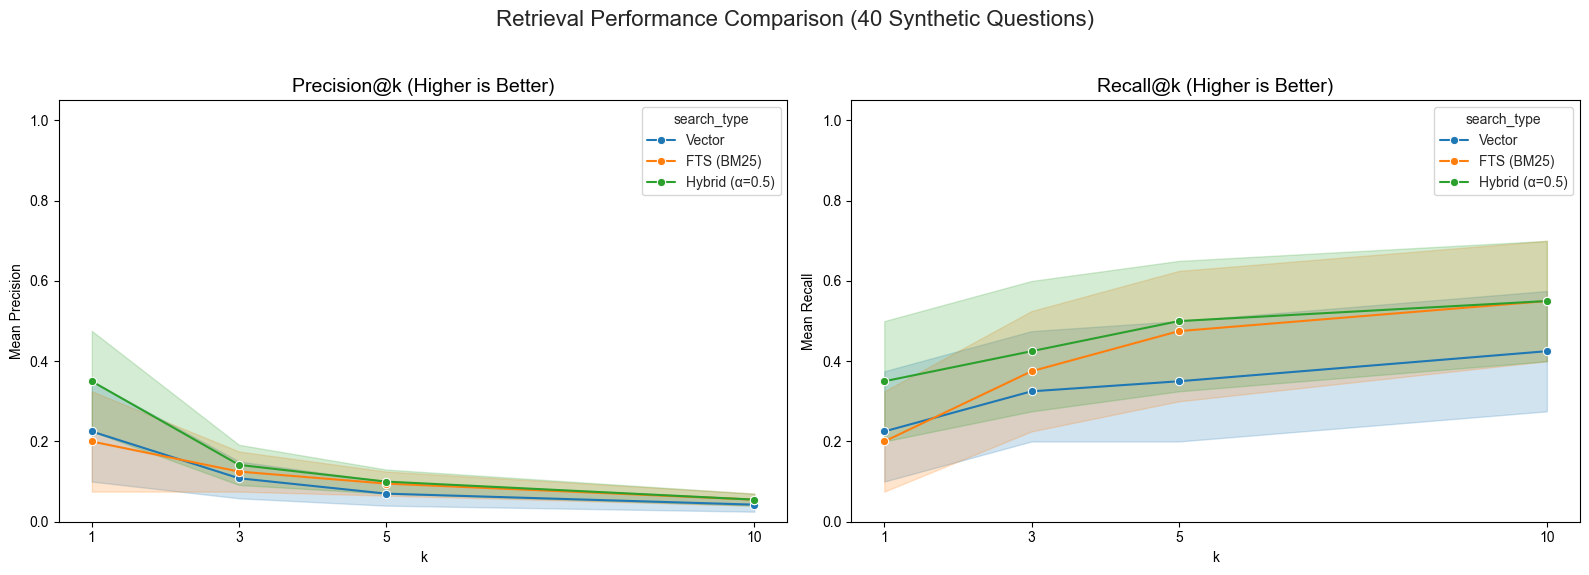

--- Summary of Mean Scores ---
metric             precision  recall
search_type    k                    
FTS (BM25)     1      0.2000   0.200
               3      0.1250   0.375
               5      0.0950   0.475
               10     0.0550   0.550
Hybrid (α=0.5) 1      0.3500   0.350
               3      0.1417   0.425
               5      0.1000   0.500
               10     0.0550   0.550
Vector         1      0.2250   0.225
               3      0.1083   0.325
               5      0.0700   0.350
               10     0.0425   0.425


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Combine all results into one DataFrame for plotting
eval_frames = []

if 'syn_eval_df' in globals():
    df_vec = syn_eval_df.copy()
    df_vec['search_type'] = 'Vector'
    eval_frames.append(df_vec)

if 'syn_eval_df_fts' in globals():
    df_fts = syn_eval_df_fts.copy()
    df_fts['search_type'] = 'FTS (BM25)'
    eval_frames.append(df_fts)

if 'syn_eval_df_hybrid' in globals():
    df_hybrid = syn_eval_df_hybrid.copy()
    df_hybrid['search_type'] = 'Hybrid (α=0.5)'
    eval_frames.append(df_hybrid)

if eval_frames:
    all_eval_df = pd.concat(eval_frames)

    # 2. Set up the figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    sns.set_style("whitegrid")

    # Plot Precision@k
    sns.lineplot(
        data=all_eval_df[all_eval_df['metric'] == 'precision'],
        x='k', y='score', hue='search_type', marker='o', ax=ax1
    )
    ax1.set_title('Precision@k (Higher is Better)', fontsize=14)
    ax1.set_ylabel('Mean Precision')
    ax1.set_ylim(0, 1.05)
    ax1.set_xticks([1, 3, 5, 10])

    # Plot Recall@k
    sns.lineplot(
        data=all_eval_df[all_eval_df['metric'] == 'recall'],
        x='k', y='score', hue='search_type', marker='o', ax=ax2
    )
    ax2.set_title('Recall@k (Higher is Better)', fontsize=14)
    ax2.set_ylabel('Mean Recall')
    ax2.set_ylim(0, 1.05)
    ax2.set_xticks([1, 3, 5, 10])

    plt.suptitle('Retrieval Performance Comparison (40 Synthetic Questions)', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # 3. Show a summary table as well
    print("--- Summary of Mean Scores ---")
    summary = all_eval_df.groupby(['search_type', 'metric', 'k'])['score'].mean().unstack(level=1).round(4)
    print(summary)
else:
    print("No evaluation dataframes found. Please run the evaluation cells for Vector, FTS, and Hybrid search first.")

# Analysis of Retrieval Performance

We evaluated three different retrieval strategies using 40 synthetic questions generated from the Fordham University website chunks.

## 📊 Results Summary
| Search Type | Precision@1 (Top-1 Accuracy) | Recall@10 |
| :--- | :---: | :---: |
| **Hybrid (α=0.5)** | **0.3500** | **0.5500** |
| Vector | 0.2250 | 0.4250 |
| FTS (BM25) | 0.2000 | 0.5500 |

## 🔍 Key Findings

1. **Hybrid Search is the Superior Strategy**: 
   - By combining Vector (Semantic) and FTS (Keyword) search with an equal weight ($\alpha=0.5$), our **Top-1 Accuracy jumped to 35%**. 
   - This suggests that neither strategy is sufficient on its own, but together they cover each other's weaknesses.

2. **The "Keyword Recall" Advantage**: 
   - Interestingly, **Full Text Search (BM25)** matched the Hybrid strategy's Recall@10 (55%), significantly beating standalone Vector search (42.5%). 
   - **Conclusion**: Our dataset contains many specific terms (program names, buildings, deadlines) that keyword search handles better than embeddings.

3. **Ranking Efficiency**: 
   - While FTS is good at "finding" the document somewhere in the list, **Vector Search** helps rank it higher. 
   - This is why the Hybrid strategy has higher Precision@1 than FTS alone, even though they find the same total number of documents in the top 10.

## 💡 Recommendations

*   **Tuning Alpha**: Since keyword recall is so strong (55%), we should experiment with decreasing $\alpha$ to **0.3** or **0.4** to give more importance to the BM25 scores.
*   **Address the Recall Ceiling**: Our best strategy still misses the correct context 45% of the time. This suggests we may need:
    *   **Better Chunking**: Smaller or more overlapping chunks.
    *   **Advanced Re-ranking**: A second-stage LLM re-ranker to look at the Top 10 results.

---

# 8. (Optional) Make it an app

So far your RAG system lives inside a notebook. That's great for development — but nobody is going to use your Jupyter notebook to ask questions about Fordham. Let's turn it into a real web app.

> 📚 **TERM: Streamlit**  
> A Python library that turns plain Python scripts into interactive web apps. You write Python — no HTML, CSS, or JavaScript — and Streamlit renders it as a web page with inputs, buttons, and formatted output. It's the fastest way to go from "I have a function" to "I have a web app."

Your task: **create a Streamlit app that lets a user type a question about Fordham and get an answer from your RAG system.**

To get started:
- Install it: `uv pip install streamlit` 
- A Streamlit app is just a `.py` file (not a notebook). Create something like `fordham_rag_app.py`
- Run it: `streamlit run scripts/fordham_rag_app.py` — this opens a browser tab with your app

Tips:
- Check out the [Streamlit docs](https://docs.streamlit.io/) — the "Get started" tutorial is very short
- Your best bet is to vibecode your way to this. You'll be surprised how fast you can get it up and running

In [21]:
# Placeholder for your implementation

from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv()
client = OpenAI()


In [22]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import streamlit as st
from dotenv import load_dotenv
from openai import OpenAI

EMBED_MODEL = "text-embedding-3-small"
CHAT_MODEL = "gpt-4o-mini"

st.set_page_config(page_title="Fordham RAG", layout="wide")
st.title("Fordham RAG Assistant")

# Paths (project root is parent of scripts/)
PROJECT_ROOT = Path.cwd().resolve().parents[0]
CHUNKS_PATH = PROJECT_ROOT / "chunks.csv"
EMB_PATH = PROJECT_ROOT / "chunk_embeddings.npy"
ENV_PATH = PROJECT_ROOT / ".env"

# Show immediate UI so page is never blank
st.write("Project root:", str(PROJECT_ROOT))
st.write("Chunks file:", str(CHUNKS_PATH))
st.write("Embeddings file:", str(EMB_PATH))

# Load env
load_dotenv(dotenv_path=ENV_PATH)

if not os.getenv("OPENAI_API_KEY"):
    st.error("OPENAI_API_KEY missing. Add it to .env in the project root.")
    st.stop()

client = OpenAI()

def load_index():
    if not CHUNKS_PATH.exists():
        raise FileNotFoundError(f"chunks.csv not found at {CHUNKS_PATH}")
    if not EMB_PATH.exists():
        raise FileNotFoundError(f"chunk_embeddings.npy not found at {EMB_PATH}")

    # Load chunks (CSV can be large)
    df = pd.read_csv(CHUNKS_PATH)

    # Load embeddings efficiently
    emb = np.load(EMB_PATH, mmap_mode="r").astype(np.float32)

    # Normalize (if already normalized, this is still safe)
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)

    return df, emb

def embed_query(q: str) -> np.ndarray:
    resp = client.embeddings.create(model=EMBED_MODEL, input=[q])
    v = np.array(resp.data[0].embedding, dtype=np.float32)
    v = v / (np.linalg.norm(v) + 1e-12)
    return v

def retrieve(df: pd.DataFrame, emb: np.ndarray, question: str, top_k: int):
    qv = embed_query(question)
    scores = emb @ qv
    idx = np.argsort(-scores)[:top_k]
    out = df.iloc[idx].copy()
    out["score"] = scores[idx]
    return out

def generate_answer(question: str, sources_df: pd.DataFrame) -> str:
    blocks = []
    for i, row in sources_df.reset_index(drop=True).iterrows():
        url = str(row.get("url", "")).strip()
        chunk = str(row.get("chunk", "")).strip()
        blocks.append(f"Source {i+1}\nURL: {url}\n\n{chunk}")

    context = "\n\n---\n\n".join(blocks)

    prompt = f"""Answer using ONLY the sources. If not found, say: I don't know based on the provided sources.
Cite sources like [Source 1], [Source 2].

Question: {question}

Sources:
{context}
"""
    resp = client.chat.completions.create(
        model=CHAT_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
    )
    return resp.choices[0].message.content

with st.sidebar:
    top_k = st.slider("Top K sources", 3, 12, 5)
    show_sources = st.checkbox("Show sources", True)

question = st.text_input("Ask a question about Fordham", placeholder="e.g., How do I apply for financial aid?")
ask = st.button("Ask")

if ask:
    if not question.strip():
        st.warning("Please type a question.")
        st.stop()

    with st.spinner("Loading index (chunks + embeddings)..."):
        try:
            df_chunks, vectors = load_index()
        except Exception as e:
            st.error("Failed to load data files.")
            st.exception(e)
            st.stop()

    st.success(f"Loaded {len(df_chunks)} chunks. Embeddings shape: {vectors.shape}")

    with st.spinner("Retrieving sources..."):
        sources = retrieve(df_chunks, vectors, question, top_k=top_k)

    with st.spinner("Generating answer..."):
        ans = generate_answer(question, sources)

    st.subheader("Answer")
    st.write(ans)

    if show_sources:
        st.subheader("Sources")
        for i, row in sources.reset_index(drop=True).iterrows():
            st.markdown(f"**Source {i+1}** | score `{row['score']:.4f}`")
            url = str(row.get("url", "")).strip()
            if url:
                st.write(url)
            st.code(str(row.get("chunk", ""))[:1200])
            st.divider()


2026-02-18 15:21:42.694 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-02-18 15:21:42.695 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-02-18 15:21:42.819 
  command:

    streamlit run /Users/pavitravenkatesh/Desktop/ai-engineering-fordham-backup/ai-engineering-fordham/.venv/lib/python3.9/site-packages/ipykernel_launcher.py [ARGUMENTS]


2026-02-18 15:21:42.819 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-02-18 15:21:42.819 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


...

2026-02-18 15:21:42.831 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-02-18 15:21:42.831 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-02-18 15:21:42.831 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-02-18 15:21:42.831 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-02-18 15:21:42.831 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


---

# Summary

## What You Built

| Step | What You Did | What It Does |
|------|-------------|-------------|
| **Load** | Read 9,500+ Fordham web pages | Get raw content |
| **Chunk** | Split pages into smaller pieces | Make content searchable and promptable |
| **Embed** | Turn chunks into vectors | Enable semantic search |
| **Retrieve** | Find relevant chunks for a question | The **R** in RAG |
| **Generate** | Ask an LLM to answer using the chunks | The **G** in RAG |
| **RAG** | Wire it all together | Question in, answer out |

## The Big Picture

RAG is one of the most common patterns in AI engineering today. What you built here is the same core architecture behind tools like ChatGPT with search, Perplexity, enterprise Q&A bots, and more. The details get more sophisticated (vector databases, reranking, query rewriting, evaluation) but the pattern is the same:

**Find relevant stuff → give it to an LLM → get an answer.**

You can just build things.